In [1]:
from transformers import AutoModelForImageClassification, AutoImageProcessor  # probably new to you
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
import torch
from PIL import Image

Materials for learning about architectures (random choice from Internet):
- [convolution](https://www.edureka.co/blog/convolutional-neural-network)
- [attentnion](https://www.geeksforgeeks.org/deep-learning/attention-mechanisms-for-computer-vision/)

## 01 Acessing inner layers - out-of-the-box scenario

In [2]:
model_name = "Emiel/cub-200-bird-classifier-swin"

processor = AutoImageProcessor.from_pretrained(model_name)
model = AutoModelForImageClassification.from_pretrained(model_name, output_hidden_states=True)  # new thing here

The image processor of type `ViTImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


Loading weights:   0%|          | 0/449 [00:00<?, ?it/s]

In [3]:
model

SwinForImageClassification(
  (swin): SwinModel(
    (embeddings): SwinEmbeddings(
      (patch_embeddings): SwinPatchEmbeddings(
        (projection): Conv2d(3, 192, kernel_size=(4, 4), stride=(4, 4))
      )
      (norm): LayerNorm((192,), eps=1e-05, elementwise_affine=True)
      (dropout): Dropout(p=0.0, inplace=False)
    )
    (encoder): SwinEncoder(
      (layers): ModuleList(
        (0): SwinStage(
          (blocks): ModuleList(
            (0): SwinLayer(
              (layernorm_before): LayerNorm((192,), eps=1e-05, elementwise_affine=True)
              (attention): SwinAttention(
                (self): SwinSelfAttention(
                  (query): Linear(in_features=192, out_features=192, bias=True)
                  (key): Linear(in_features=192, out_features=192, bias=True)
                  (value): Linear(in_features=192, out_features=192, bias=True)
                  (dropout): Dropout(p=0.0, inplace=False)
                )
                (output): SwinSelfOutput(

In [4]:
root_path = '/mnt/ml/resources/wb2/CUB_200_2011/CUB_200_2011/images'
def sample_image(root: str = root_path, return_cls: bool = True):
    paths = list(Path(root).rglob('*.jpg'))
    rand_idx = np.random.choice(len(paths))
    
    path = paths[rand_idx]
    
    if return_cls:
        class_idx = int(path.parent.name[:3]) - 1
        return path, class_idx
    else:
        return path

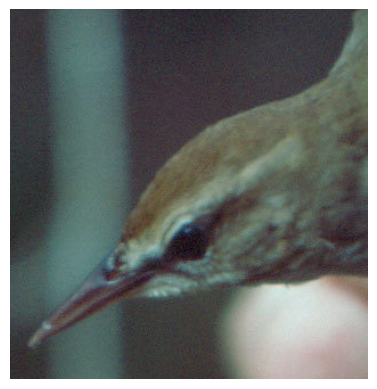

Predicted class: 177; true class: 177


In [5]:
path, class_idx = sample_image()

img = Image.open(path).convert("RGB")
plt.imshow(img)
plt.axis('off')
plt.show()

inputs = processor(images=img, return_tensors="pt")

with torch.no_grad():
    output = model(**inputs)
    pred = torch.argmax(output.logits, dim=-1).item()
    
print(f"Predicted class: {pred}; true class: {class_idx}")

In [6]:
output.keys()

odict_keys(['logits', 'hidden_states', 'reshaped_hidden_states'])

In [7]:
output.hidden_states

(tensor([[[-0.9856,  0.0292, -0.1771,  ...,  0.5660, -1.7030,  0.6106],
          [-1.2274,  0.0293, -0.1776,  ...,  1.0186, -1.3972,  0.7110],
          [-0.7127,  0.0289, -0.1797,  ...,  0.3951, -1.3597,  0.1422],
          ...,
          [ 0.9018,  0.0220, -0.1813,  ..., -0.4391, -1.4661,  0.1587],
          [ 0.0700,  0.0222, -0.1828,  ...,  0.0730, -1.5821,  0.5491],
          [ 0.5930,  0.0225, -0.1833,  ..., -0.2970, -1.5031,  0.6687]]]),
 tensor([[[ 2.1919, -0.9217,  1.0569,  ...,  1.0350, -1.5849,  0.3259],
          [ 2.0103,  0.5082, -0.8293,  ..., -0.2081, -1.2794, -0.9452],
          [ 2.0079, -1.3375,  0.5933,  ..., -0.8707, -0.7824,  0.3804],
          ...,
          [-2.1592, -0.7341,  2.0330,  ...,  0.1764, -0.5001,  0.8188],
          [-1.7095,  0.2063, -0.4400,  ...,  0.2537, -1.6758, -0.0881],
          [-1.6015, -1.1084, -0.6748,  ...,  0.0231, -0.7724,  0.4024]]]),
 tensor([[[ 1.4882,  0.7761, -1.0186,  ..., -0.4697,  0.4041,  0.1834],
          [ 2.1650,  0.0996,

for this model, hidden_states are cpatured for each `stage`

In [8]:
for i, layer_state in enumerate(output.hidden_states):
    print(f"Layer {i} -> shape {layer_state.shape}, min={layer_state.min():.4f}, max={layer_state.max():.4f}")

Layer 0 -> shape torch.Size([1, 9216, 192]), min=-6.9228, max=10.3202
Layer 1 -> shape torch.Size([1, 2304, 384]), min=-8.2513, max=10.3402
Layer 2 -> shape torch.Size([1, 576, 768]), min=-11.1634, max=14.0762
Layer 3 -> shape torch.Size([1, 144, 1536]), min=-356.8831, max=154.4703
Layer 4 -> shape torch.Size([1, 144, 1536]), min=-479.1576, max=250.4830


## 02 - accessing model inner layers - more general approach

In [9]:
activations = {}

def hook_fn(module, input, output):
    activations[module] = output

# Example: hook on first block of first stage
hook = model.swin.encoder.layers[0].blocks[0].register_forward_hook(hook_fn)

with torch.no_grad():
# Forward pass
    outputs = model(**inputs)

print(activations)
hook.remove()

{SwinLayer(
  (layernorm_before): LayerNorm((192,), eps=1e-05, elementwise_affine=True)
  (attention): SwinAttention(
    (self): SwinSelfAttention(
      (query): Linear(in_features=192, out_features=192, bias=True)
      (key): Linear(in_features=192, out_features=192, bias=True)
      (value): Linear(in_features=192, out_features=192, bias=True)
      (dropout): Dropout(p=0.0, inplace=False)
    )
    (output): SwinSelfOutput(
      (dense): Linear(in_features=192, out_features=192, bias=True)
      (dropout): Dropout(p=0.0, inplace=False)
    )
  )
  (drop_path): Identity()
  (layernorm_after): LayerNorm((192,), eps=1e-05, elementwise_affine=True)
  (intermediate): SwinIntermediate(
    (dense): Linear(in_features=192, out_features=768, bias=True)
    (intermediate_act_fn): GELUActivation()
  )
  (output): SwinOutput(
    (dense): Linear(in_features=768, out_features=192, bias=True)
    (dropout): Dropout(p=0.0, inplace=False)
  )
): (tensor([[[-1.7853, -1.2641, -0.4261,  ..., -0.3

In [10]:
activations.values()

dict_values([(tensor([[[-1.7853, -1.2641, -0.4261,  ..., -0.3114, -0.9286,  0.7847],
         [-2.4265, -1.0818, -0.6275,  ...,  0.8245, -0.8331,  1.2172],
         [-0.9900, -0.9209,  0.3434,  ..., -0.6429,  0.2315, -0.3720],
         ...,
         [ 2.0259, -0.5000,  0.4478,  ..., -0.6939,  0.9212, -1.3715],
         [-0.7288, -0.2030,  0.0249,  ...,  0.4612,  0.4056, -0.7047],
         [ 0.5861, -0.6533,  0.2178,  ..., -0.8163,  0.8820, -0.3146]]]),)])

## 03 - Let's find out where is the information about `yellow_tail`

In [11]:
from torch.utils.data import Dataset, DataLoader
from typing import Literal, Any
import pandas as pd
from tqdm import tqdm

In [12]:
class Cub200Dataset(Dataset):
    
    def __init__(self, path: str, split: Literal["train", "test"], processor) -> None:
        super().__init__()
        
        self.path = Path(path)
        self.split = split
        
        self.metadata = pd.read_csv(self.path / 'images.txt', sep=' ')
        self.metadata.columns = ['id', 'path']
        
        split_data = pd.read_csv(self.path / "train_test_split.txt", sep=' ')
        split_data.columns = ['id', 'is_train']
        
        self.metadata = pd.merge(self.metadata, split_data, on="id")
        if self.split == 'train':
            self.metadata = self.metadata[self.metadata['is_train'] == 1]
        else:
            self.metadata = self.metadata[self.metadata['is_train'] == 0]
        self.metadata.reset_index(drop=True, inplace=True)
        
        self.processor = processor
        
        # new part here
        labels = pd.read_csv(self.path / 'attributes' / 'image_attribute_labels.txt',
                             sep=' ', 
                             usecols=[0,1,2],
                             header=None)
        labels = pd.pivot(labels, index=0, columns=1, values=2)
        labels_names = pd.read_csv(self.path / 'attributes' / 'attributes.txt', 
                                   sep=' ',
                                   usecols=[1],
                                   header=None)
        labels.columns = labels_names.iloc[:,0].to_list()
        labels = labels.reset_index(drop=False)
        labels = labels.rename(columns={0: 'id'})
        self.metadata = pd.merge(self.metadata, labels, how='left', on='id')
        
    def __len__(self) -> int:
        return self.metadata.shape[0]
    
    def __getitem__(self, index) -> Any:
        path = self.metadata.iloc[index]['path']
        img = Image.open(str(self.path / 'images' / path)).convert('RGB')
        inputs = processor(images=img, return_tensors="pt")
        inputs['pixel_values'] = inputs['pixel_values'][0,:,:,:]
        class_idx = int(Path(path).parent.name[:3]) - 1
        
        return inputs, class_idx, dict(self.metadata.iloc[index,3:])

In [13]:
root_path = '/mnt/ml/resources/wb2/CUB_200_2011/CUB_200_2011'

dataset = Cub200Dataset(root_path, 'test', processor=processor)
dataset.metadata.columns[dataset.metadata.columns.str.startswith('has_primary_color')]

Index(['has_primary_color::blue', 'has_primary_color::brown',
       'has_primary_color::iridescent', 'has_primary_color::purple',
       'has_primary_color::rufous', 'has_primary_color::grey',
       'has_primary_color::yellow', 'has_primary_color::olive',
       'has_primary_color::green', 'has_primary_color::pink',
       'has_primary_color::orange', 'has_primary_color::black',
       'has_primary_color::white', 'has_primary_color::red',
       'has_primary_color::buff'],
      dtype='object')

In [14]:
dataloader = DataLoader(dataset, batch_size=64, shuffle=True)

model.to('cuda')

# repeat from previous cells
activations = []
def hook_fn(module, input, output):
    activations.append(output)
hook = model.swin.encoder.layers[2].blocks[-1].register_forward_hook(hook_fn)  # ~middle layers

ys = []
preds = []
with torch.no_grad():
    for idx, batch in enumerate(tqdm(dataloader)):
        X, _, attrs = batch
        y = attrs['has_primary_color::yellow']
        X.to('cuda')
        
        _ = model(**X)
        
        ys.append(y)
        
        if idx == 5:
            break
        
hook.remove()

  5%|▌         | 5/91 [00:16<04:37,  3.23s/it]


In [15]:
ys = torch.concat(ys).to('cpu')

activations = [act[0] for act in activations]
activations = torch.concat(activations).to('cpu')

In [16]:
ys.shape

torch.Size([384])

In [17]:
activations.shape

torch.Size([384, 576, 768])

In [18]:
activations = torch.flatten(activations, start_dim=1)

In [19]:
ys = ys.to('cpu').numpy()
activations = activations.to('cpu').numpy()

In [20]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import SGDClassifier

In [47]:
X_train, X_test, y_train, y_test = train_test_split(activations,
                                                    ys,
                                                    test_size=0.1,
                                                    stratify=ys,
                                                    random_state=123)

classifier = SGDClassifier(penalty='elasticnet', alpha=0.1, max_iter=1)
for _ in tqdm(range(20)):
    classifier.partial_fit(X_train, y_train, classes=[0, 1])

100%|██████████| 20/20 [00:41<00:00,  2.06s/it]


In [48]:
from sklearn.metrics import f1_score, roc_auc_score

y_pred = classifier.predict(X_test)

print(f"Accuracy: {(y_test == y_pred).mean():.3f}")
print(f"F1: {f1_score(y_test, y_pred):.3f}")
print(f"ROC-AUC: {roc_auc_score(y_test, y_pred):.3f}")

Accuracy: 0.897
F1: 0.667
ROC-AUC: 0.803


... But we made super naive classification. Let's make PatCAV

In [49]:
def cosine_similarity(v, M):
    v = v.reshape(1, -1)

    dot = M @ v.T
    v_norm = np.linalg.norm(v)
    M_norm = np.linalg.norm(M, axis=1, keepdims=True)

    cos = dot / (M_norm * v_norm)
    return cos.squeeze()

In [50]:
X_pos, X_neg = X_train[y_train == 1], X_train[y_train == 0]
sv = X_pos.mean(axis=0) - X_neg.mean(axis=0)

cossims = cosine_similarity(sv, X_test)
cossims  # none are above 0.5, but it doesn't matter for ROC-AUc - only order is important

array([0.2707293 , 0.33240473, 0.273468  , 0.321071  , 0.28054285,
       0.43316436, 0.28465733, 0.26304686, 0.30382094, 0.29948464,
       0.25936937, 0.36777353, 0.40211052, 0.25100556, 0.28592587,
       0.32401413, 0.28554326, 0.4030634 , 0.42284667, 0.26571563,
       0.31721595, 0.3009598 , 0.26116237, 0.32016647, 0.26796892,
       0.25548238, 0.31765535, 0.44119412, 0.25570112, 0.34199637,
       0.42278707, 0.38964212, 0.28555644, 0.25714484, 0.2847664 ,
       0.318624  , 0.2845203 , 0.29719812, 0.32001233], dtype=float32)

In [51]:
roc_auc_score(y_test, cossims)  # so model can recognize color in the middle layers!

0.9494949494949495

*Note*: all experiments here are made on **really** small subsample of data - we did it for the sake of time, but we should definetly make more experiments.